In [ ]:
import json
import os
import requests
import time
import pandas as pd

def read_jsonl(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

def get_citations_semantic_scholar(title, max_retries=3):
    """
    Get citation count from Semantic Scholar API
    """
    base_url = "https://api.semanticscholar.org/graph/v1/paper/search"
    
    for attempt in range(max_retries):
        try:
            # Search for the paper by title
            params = {
                'query': title,
                'limit': 1,
                'fields': 'title,citationCount,year,authors'
            }
            
            response = requests.get(base_url, params=params, timeout=10)
            
            if response.status_code == 200:
                data = response.json()
                if data['data']:
                    paper = data['data'][0]
                    return {
                        'title': paper.get('title', 'N/A'),
                        'citation_count': paper.get('citationCount', 0),
                        'year': paper.get('year', 'N/A'),
                        'authors': paper.get('authors', [])
                    }
                else:
                    return {'title': title, 'citation_count': 0, 'year': 'N/A', 'authors': []}
            
            elif response.status_code == 429:  # Rate limited
                wait_time = 2 ** attempt
                print(f"Rate limited. Waiting {wait_time} seconds...")
                time.sleep(wait_time)
                continue
            else:
                print(f"Error {response.status_code} for title: {title}")
                return {'title': title, 'citation_count': 0, 'year': 'N/A', 'authors': []}
                
        except Exception as e:
            print(f"Exception for title '{title}': {e}")
            if attempt < max_retries - 1:
                time.sleep(1)
                continue
            return {'title': title, 'citation_count': 0, 'year': 'N/A', 'authors': []}
    
    return {'title': title, 'citation_count': 0, 'year': 'N/A', 'authors': []}

def get_all_citations(unique_titles, delay=1):
    """
    Get citation counts for all unique paper titles
    """
    print(f"Getting citations for {len(unique_titles)} unique papers...")
    
    all_citations = []
    
    for i, title in enumerate(unique_titles):
        print(f"Progress: {i+1}/{len(unique_titles)} - {title[:50]}...")
        
        result = get_citations_semantic_scholar(title)
        result['original_title'] = title  # Keep original title for merging
        all_citations.append(result)
        
        # Add delay to be respectful to the API
        if i < len(unique_titles) - 1:  # Don't sleep after the last request
            time.sleep(delay)
    
    return pd.DataFrame(all_citations)

paths = ["data/release_folder/train1", "data/release_folder/train2", "data/release_folder/test", "data/release_folder/validation"]
languages = ["en", "es", "fr", "hi", "it"]

language_dataframes = {}

for lan in languages:
    print(f"\n=== Processing language: {lan} ===")
    language_dfs = []  
    
    for path in paths:
        if path.split("/")[-1] == "train1":
            name = "train"
        elif path.split("/")[-1] == "validation":
            name = "valid"
        else: 
            name = path.split("/")[-1]

        file_1 = os.path.join(path, f'{lan}_{name}_data.jsonl')
        file_2 = os.path.join(path, f'{lan}_{name}_label.jsonl')

        if not (os.path.exists(file_1) and os.path.exists(file_2)):
            print(f"Files not found for {lan}_{name}, skipping...")
            continue

        data = read_jsonl(file_1)
        labels = read_jsonl(file_2)

        assert len(data) == len(labels)

        data_df = pd.DataFrame(data)
        labels_df = pd.DataFrame(labels)

        df = pd.merge(data_df, labels_df, on='index')

        df['has_fluency_mistakes'] = df['has_fluency_mistakes'].map({'y': True, 'n': False})
        df['has_factual_mistakes'] = df['has_factual_mistakes'].map({'y': True, 'n': False})
        
        # Add dataset split information
        df['dataset_split'] = name
        
        language_dfs.append(df)
        print(f"Loaded {len(df)} entries from {lan}_{name}")
    
    # Merge all dataframes for this language
    if language_dfs:
        merged_df = pd.concat(language_dfs, ignore_index=True)
        print(f"Total entries for {lan}: {len(merged_df)}")
        
        # Get unique paper titles for citation lookup
        unique_titles = merged_df['title'].unique()
        print(f"Unique papers for {lan}: {len(unique_titles)}")
        
        # Get citations for all unique papers
        citation_data = get_all_citations(unique_titles, delay=1)
        
        # Merge citation data back with the language dataframe
        merged_df_with_citations = merged_df.merge(
            citation_data[['original_title', 'citation_count', 'year']], 
            left_on='title', 
            right_on='original_title', 
            how='left'
        )
        
        # Store in dictionary
        language_dataframes[lan] = merged_df_with_citations
        
        # Save the processed dataframe with citations back to release_folder
        output_file = os.path.join("data/release_folder/full", f"{lan}.jsonl")
        
        # Convert to records and save as JSONL
        records = merged_df_with_citations.to_dict('records')
        with open(output_file, 'w', encoding='utf-8') as f:
            for record in records:
                f.write(json.dumps(record, ensure_ascii=False) + '\n')
        
        print(f"Saved {len(merged_df_with_citations)} entries to {output_file}")
        
        # Display summary for this language
        print(f"\n{lan.upper()} Citation statistics:")
        print(f"Mean citations: {merged_df_with_citations['citation_count'].mean():.1f}")
        print(f"Median citations: {merged_df_with_citations['citation_count'].median():.1f}")
        print(f"Max citations: {merged_df_with_citations['citation_count'].max()}")
        
        # Show top cited papers for this language
        print(f"\nTop 5 most cited papers in {lan.upper()}:")
        top_cited = merged_df_with_citations.drop_duplicates('title').nlargest(5, 'citation_count')
        print(top_cited[['title', 'citation_count', 'year']])
        
        print(f"Completed processing for {lan}")
    else:
        print(f"No data found for language {lan}")

print(f"Languages processed: {list(language_dataframes.keys())}")
for lang, df in language_dataframes.items():
    print(f"{lang}: {len(df)} total entries, {df['title'].nunique()} unique papers")






=== Processing language: en ===
Loaded 24 entries from en_train
Loaded 84 entries from en_train2
Loaded 240 entries from en_test
Loaded 240 entries from en_valid
Total entries for en: 588
Unique papers for en: 98
Getting citations for 98 unique papers...
Progress: 1/98 - Extrinsic Evaluation of Machine Translation Metric...
Rate limited. Waiting 1 seconds...
Rate limited. Waiting 1 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Progress: 2/98 - COKE: A Cognitive Knowledge Graph for Machine Theo...
Progress: 2/98 - COKE: A Cognitive Knowledge Graph for Machine Theo...
Rate limited. Waiting 1 seconds...
Rate limited. Waiting 1 seconds...
Progress: 3/98 - G-DIG: Towards Gradient-based DIverse and hiGh-qua...
Progress: 3/98 - G-DIG: Towards Gradient-based DIverse and hiGh-qua...
Progress: 4/98 - Climbing towards NLU: On Meaning, Form, and Unders...
Progress: 4/98 - Climbing towards NLU: On Meaning, Form, and Unders...
Rate limited. Waiting 1 seconds...
Ra

## Correct failed citation queries in existing full dataset files

In [ ]:
import json
import os
import requests
import time
import pandas as pd

def read_jsonl(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

def write_jsonl(data, file_path):
    with open(file_path, 'w', encoding='utf-8') as f:
        for record in data:
            f.write(json.dumps(record, ensure_ascii=False) + '\n')

def get_citations_semantic_scholar(title, max_retries=3):
    """
    Get citation count from Semantic Scholar API
    """
    base_url = "https://api.semanticscholar.org/graph/v1/paper/search"
    
    for attempt in range(max_retries):
        try:
            # Search for the paper by title
            params = {
                'query': title,
                'limit': 1,
                'fields': 'title,citationCount,year,authors'
            }
            
            response = requests.get(base_url, params=params, timeout=10)
            
            if response.status_code == 200:
                data = response.json()
                if data['data']:
                    paper = data['data'][0]
                    return {
                        'citation_count': paper.get('citationCount', 0),
                        'year': paper.get('year', 'N/A'),
                        'found': True
                    }
                else:
                    return {'citation_count': 0, 'year': 'N/A', 'found': False}
            
            elif response.status_code == 429:  # Rate limited
                wait_time = 2 ** attempt
                print(f"Rate limited. Waiting {wait_time} seconds...")
                time.sleep(wait_time)
                continue
            else:
                print(f"Error {response.status_code} for title: {title}")
                return {'citation_count': 0, 'year': 'N/A', 'found': False}
                
        except Exception as e:
            print(f"Exception for title '{title}': {e}")
            if attempt < max_retries - 1:
                time.sleep(1)
                continue
            return {'citation_count': 0, 'year': 'N/A', 'found': False}
    
    return {'citation_count': 0, 'year': 'N/A', 'found': False}

# Languages to process
languages = ["en", "es", "fr", "hi", "it"]

for lan in languages:
    print(f"\n=== Correcting failed queries for language: {lan} ===")
    
    # Path to the full dataset file
    full_file = os.path.join("data/release_folder/full", f"{lan}.jsonl")
    
    # Check if file exists
    if not os.path.exists(full_file):
        print(f"File not found: {full_file}, skipping...")
        continue
    
    # Read the existing data
    print(f"Reading {full_file}...")
    data = read_jsonl(full_file)
    print(f"Loaded {len(data)} entries")
    
    # Find entries with failed citation queries (year='N/A')
    failed_entries = [i for i, entry in enumerate(data) if entry.get('year') == 'N/A']
    print(f"Found {len(failed_entries)} entries with failed citation queries")
    
    if len(failed_entries) == 0:
        print(f"No failed queries found for {lan}, skipping...")
        continue
    
    # Get unique titles that failed
    failed_titles = list(set([data[i]['title'] for i in failed_entries]))
    print(f"Unique failed titles: {len(failed_titles)}")
    
    # Retry citation queries for failed titles
    corrected_citations = {}
    successful_corrections = 0
    
    for i, title in enumerate(failed_titles):
        print(f"Retrying {i+1}/{len(failed_titles)}: {title[:50]}...")
        
        result = get_citations_semantic_scholar(title)
        corrected_citations[title] = result
        
        if result['found']:
            successful_corrections += 1
            print(f"  ✓ Found: {result['citation_count']} citations, year: {result['year']}")
        else:
            print(f"  ✗ Still failed")
        
        # Add delay to be respectful to the API
        if i < len(failed_titles) - 1:
            time.sleep(1)
    
    print(f"Successfully corrected {successful_corrections}/{len(failed_titles)} failed queries")
    
    # Update the data with corrected citations
    updates_made = 0
    for i in failed_entries:
        title = data[i]['title']
        if title in corrected_citations and corrected_citations[title]['found']:
            data[i]['citation_count'] = corrected_citations[title]['citation_count']
            data[i]['year'] = corrected_citations[title]['year']
            updates_made += 1
    
    print(f"Updated {updates_made} entries with corrected citation data")
    
    # Save the corrected data back to file
    if updates_made > 0:
        print(f"Saving corrected data to: {full_file}")
        write_jsonl(data, full_file)
        
        # Verify the correction
        remaining_failed = sum(1 for entry in data if entry.get('year') == 'N/A')
        print(f"Remaining failed queries: {remaining_failed}")
    
    print(f"Completed corrections for {lan}")

print(f"\n=== CORRECTION SUMMARY ===")
print("All languages processed for citation correction")


=== Correcting failed queries for language: en ===
Reading data/release_folder/full/en.jsonl...
Loaded 588 entries
Found 0 entries with failed citation queries
No failed queries found for en, skipping...

=== Correcting failed queries for language: es ===
Reading data/release_folder/full/es.jsonl...
Loaded 660 entries
Found 0 entries with failed citation queries
No failed queries found for es, skipping...

=== Correcting failed queries for language: fr ===
Reading data/release_folder/full/fr.jsonl...
Loaded 1000 entries
Found 0 entries with failed citation queries
No failed queries found for fr, skipping...

=== Correcting failed queries for language: hi ===
Reading data/release_folder/full/hi.jsonl...
Loaded 1063 entries
Found 0 entries with failed citation queries
No failed queries found for hi, skipping...

=== Correcting failed queries for language: it ===
Reading data/release_folder/full/it.jsonl...
Loaded 1000 entries
Found 8 entries with failed citation queries
Unique failed ti

=== Loading full datasets ===
Loading en...
  588 entries, 98 unique papers
Loading es...
  660 entries, 88 unique papers
Loading fr...
  1000 entries, 100 unique papers
Loading hi...
  1063 entries, 100 unique papers
Loading it...
  1000 entries, 100 unique papers
Loading hi...
  1063 entries, 100 unique papers
Loading it...
  1000 entries, 100 unique papers

Loaded data for 5 languages

=== SUMMARY STATISTICS BY LANGUAGE ===
Language Code  Total Entries  Unique Papers  Mean Citations  Median Citations  Max Citations  Fluency Mistake Rate  Factual Mistake Rate  Fluency Correlation  Factual Correlation
 English   en            588             98         657.102              27.0          29637                 0.152                 0.819               -0.104               -0.173
 Spanish   es            660             88         481.398              28.5          29637                 0.259                 0.675                0.259               -0.239
  French   fr           1000    

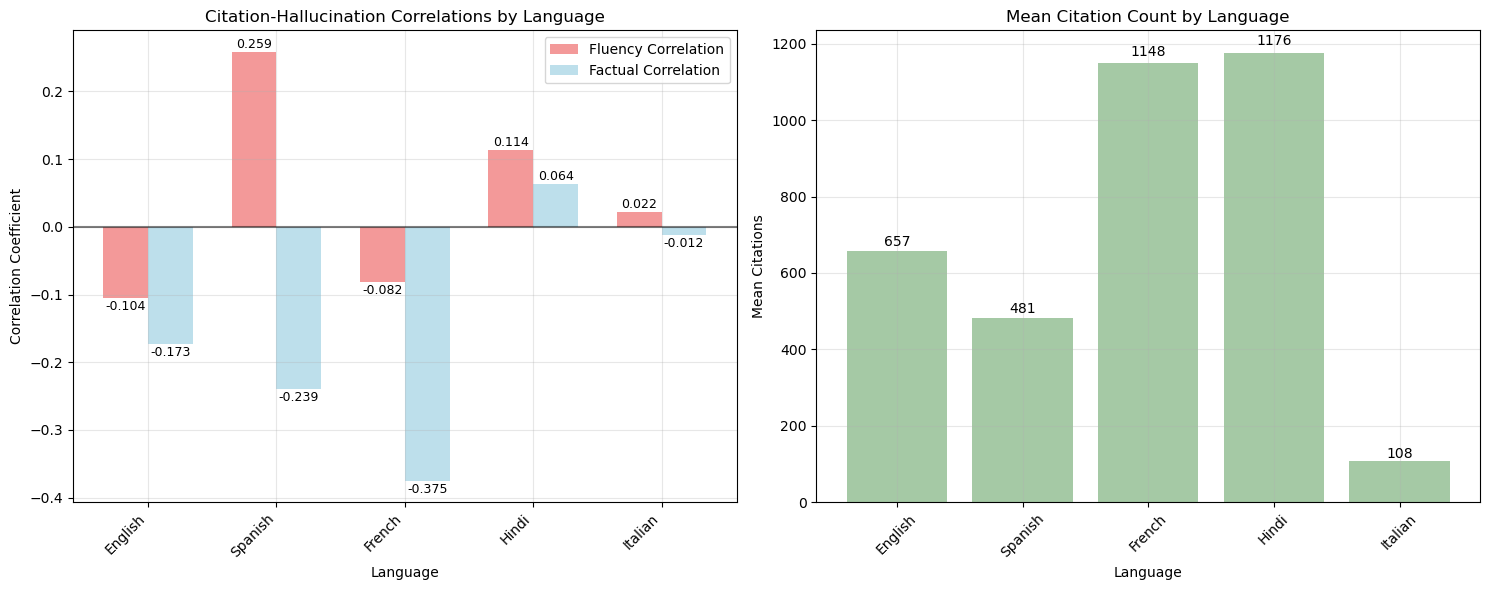


Strongest fluency correlation: Spanish (0.259)
Strongest factual correlation: French (-0.375)


In [53]:
# Read all full datasets and analyze citation-hallucination relationship by language
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def read_jsonl(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

# Languages to analyze
languages = ["en", "es", "fr", "hi", "it"]
language_names = {"en": "English", "es": "Spanish", "fr": "French", "hi": "Hindi", "it": "Italian"}

# Dictionary to store dataframes for each language
all_language_data = {}

print("=== Loading full datasets ===")
for lan in languages:
    full_file = os.path.join("data/release_folder/full", f"{lan}.jsonl")
    
    if os.path.exists(full_file):
        print(f"Loading {lan}...")
        data = read_jsonl(full_file)
        df = pd.DataFrame(data)

        all_language_data[lan] = df
        print(f"  {len(df)} entries, {df['title'].nunique()} unique papers")
    else:
        print(f"File not found: {full_file}")

print(f"\nLoaded data for {len(all_language_data)} languages")



# Create summary statistics table
print("\n=== SUMMARY STATISTICS BY LANGUAGE ===")
summary_data = []

for lan, df in all_language_data.items():
    paper_stats = df.groupby('title').agg({
        'citation_count': 'first',
        'has_fluency_mistakes': 'mean',
        'has_factual_mistakes': 'mean'
    }).reset_index()
    
    fluency_corr = paper_stats['citation_count'].corr(paper_stats['has_fluency_mistakes'])
    factual_corr = paper_stats['citation_count'].corr(paper_stats['has_factual_mistakes'])
    
    summary_data.append({
        'Language': language_names[lan],
        'Code': lan,
        'Total Entries': len(df),
        'Unique Papers': len(paper_stats),
        'Mean Citations': paper_stats['citation_count'].mean(),
        'Median Citations': paper_stats['citation_count'].median(),
        'Max Citations': paper_stats['citation_count'].max(),
        'Fluency Mistake Rate': paper_stats['has_fluency_mistakes'].mean(),
        'Factual Mistake Rate': paper_stats['has_factual_mistakes'].mean(),
        'Fluency Correlation': fluency_corr,
        'Factual Correlation': factual_corr
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.round(3).to_string(index=False))

# Create correlation comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Correlation comparison - using manual bar plotting for better control
x_pos = np.arange(len(summary_df))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, summary_df['Fluency Correlation'], width, 
                label='Fluency Correlation', alpha=0.8, color='lightcoral')
bars2 = ax1.bar(x_pos + width/2, summary_df['Factual Correlation'], width,
                label='Factual Correlation', alpha=0.8, color='lightblue')

ax1.set_xlabel('Language')
ax1.set_ylabel('Correlation Coefficient')
ax1.set_title('Citation-Hallucination Correlations by Language')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(summary_df['Language'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001 if height >= 0 else height - 0.003,
             f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001 if height >= 0 else height - 0.003,
             f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

# Citation statistics comparison
bars3 = ax2.bar(summary_df['Language'], summary_df['Mean Citations'], 
                alpha=0.8, color='darkseagreen')

ax2.set_xlabel('Language')
ax2.set_ylabel('Mean Citations')
ax2.set_title('Mean Citation Count by Language')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

strongest_fluency = summary_df.loc[summary_df['Fluency Correlation'].abs().idxmax()]
strongest_factual = summary_df.loc[summary_df['Factual Correlation'].abs().idxmax()]

print(f"\nStrongest fluency correlation: {strongest_fluency['Language']} ({strongest_fluency['Fluency Correlation']:.3f})")
print(f"Strongest factual correlation: {strongest_factual['Language']} ({strongest_factual['Factual Correlation']:.3f})")

Computing general hallucination rates per language...
Available columns in en: ['index', 'title', 'abstract', 'doi', 'url', 'extracted', 'datafile', 'authors', 'question', 'model_id', 'model_config', 'prompt', 'output_text', 'output_tokens', 'output_logits', 'has_fluency_mistakes', 'has_factual_mistakes', 'dataset_split', 'original_title', 'citation_count', 'year']
Sample data shape: (588, 21)

First few rows:
        index                                              title  \
0  en-train-0  Extrinsic Evaluation of Machine Translation Me...   
1  en-train-1  COKE: A Cognitive Knowledge Graph for Machine ...   
2  en-train-2  G-DIG: Towards Gradient-based DIverse and hiGh...   
3  en-train-3  Climbing towards NLU: On Meaning, Form, and Un...   
4  en-train-4  A Balanced Data Approach for Evaluating Cross-...   

                                            abstract  \
0  Automatic machine translation (MT) metrics are...   
1  Theory of mind (ToM) refers to humans’ ability...   
2  Large 

/tmp/ipykernel_1620128/4032368526.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(halluc_rates_df['Language'], rotation=45, ha='right')


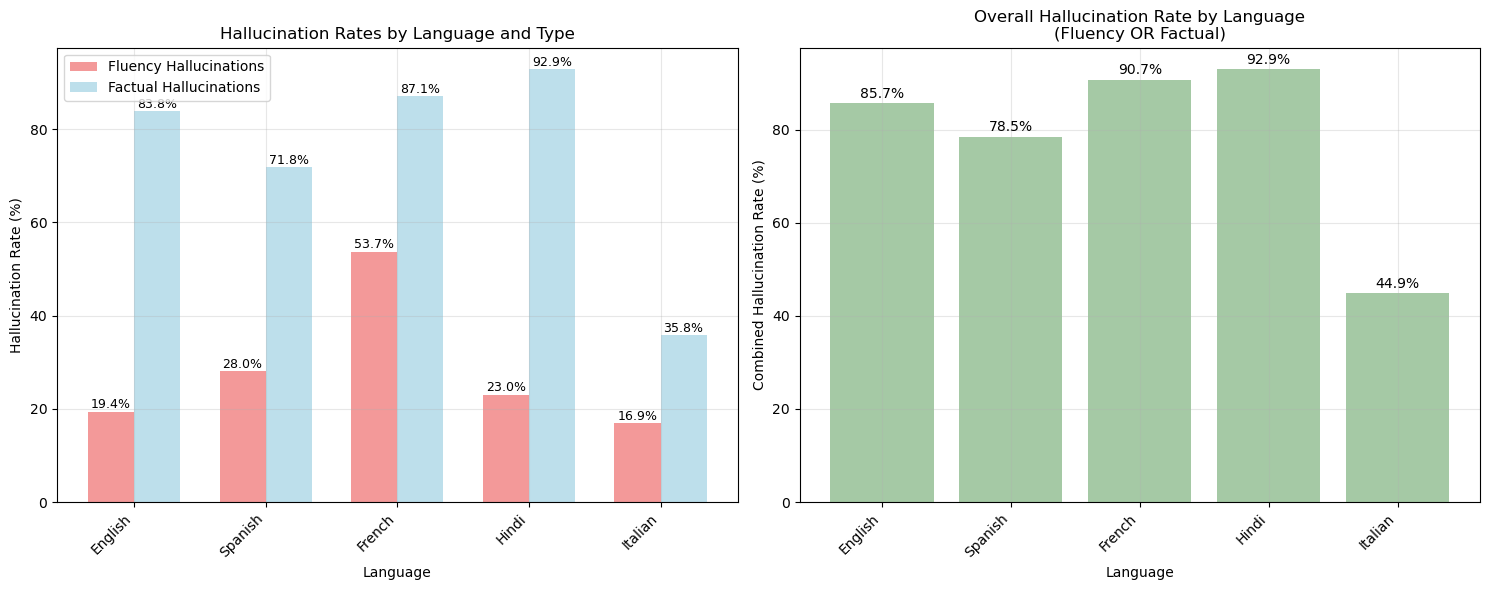


Summary Statistics:
Average fluency hallucination rate: 28.21%
Average factual hallucination rate: 74.28%
Average combined hallucination rate: 78.55%

Language with highest fluency hallucination rate: French (53.70%)
Language with highest factual hallucination rate: Hindi (92.85%)
Language with highest combined hallucination rate: Hindi (92.94%)


In [49]:
# Plot general hallucination rates per language
print("Computing general hallucination rates per language...")

# First, let's check what columns are available
sample_lang = list(all_language_data.keys())[0]
sample_df = all_language_data[sample_lang]
print(f"Available columns in {sample_lang}: {list(sample_df.columns)}")
print(f"Sample data shape: {sample_df.shape}")
print("\nFirst few rows:")
print(sample_df.head())

# Calculate hallucination rates for each language
hallucination_rates = []

for lang, df in all_language_data.items():
    total_samples = len(df)
    
    # Use the correct column names
    fluency_hallucs = df['has_fluency_mistakes'].sum()
    factual_hallucs = df['has_factual_mistakes'].sum()
    
    fluency_rate = (fluency_hallucs / total_samples) * 100
    factual_rate = (factual_hallucs / total_samples) * 100
    
    hallucination_rates.append({
        'Language': language_names.get(lang, lang.capitalize()),
        'Fluency_Rate': fluency_rate,
        'Factual_Rate': factual_rate,
        'Total_Samples': total_samples
    })

halluc_rates_df = pd.DataFrame(hallucination_rates)
print("\nHallucination rates per language:")
print(halluc_rates_df.round(2))

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Bar chart comparing fluency and factual hallucination rates
x_pos = np.arange(len(halluc_rates_df))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, halluc_rates_df['Fluency_Rate'], width, 
                label='Fluency Hallucinations', alpha=0.8, color='lightcoral')
bars2 = ax1.bar(x_pos + width/2, halluc_rates_df['Factual_Rate'], width,
                label='Factual Hallucinations', alpha=0.8, color='lightblue')

ax1.set_xlabel('Language')
ax1.set_ylabel('Hallucination Rate (%)')
ax1.set_title('Hallucination Rates by Language and Type')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(halluc_rates_df['Language'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 2: Combined hallucination rate (either fluency OR factual)
combined_rates = []
for lang, df in all_language_data.items():
    # Count samples that have either fluency or factual hallucinations (or both)
    combined_hallucs = ((df['has_fluency_mistakes'] == True) | (df['has_factual_mistakes'] == True)).sum()
    combined_rate = (combined_hallucs / len(df)) * 100
    combined_rates.append(combined_rate)

halluc_rates_df['Combined_Rate'] = combined_rates

bars3 = ax2.bar(halluc_rates_df['Language'], halluc_rates_df['Combined_Rate'], 
                alpha=0.8, color='darkseagreen')

ax2.set_xlabel('Language')
ax2.set_ylabel('Combined Hallucination Rate (%)')
ax2.set_title('Overall Hallucination Rate by Language\n(Fluency OR Factual)')
ax2.set_xticklabels(halluc_rates_df['Language'], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Average fluency hallucination rate: {halluc_rates_df['Fluency_Rate'].mean():.2f}%")
print(f"Average factual hallucination rate: {halluc_rates_df['Factual_Rate'].mean():.2f}%")
print(f"Average combined hallucination rate: {halluc_rates_df['Combined_Rate'].mean():.2f}%")

print(f"\nLanguage with highest fluency hallucination rate: {halluc_rates_df.loc[halluc_rates_df['Fluency_Rate'].idxmax(), 'Language']} ({halluc_rates_df['Fluency_Rate'].max():.2f}%)")
print(f"Language with highest factual hallucination rate: {halluc_rates_df.loc[halluc_rates_df['Factual_Rate'].idxmax(), 'Language']} ({halluc_rates_df['Factual_Rate'].max():.2f}%)")
print(f"Language with highest combined hallucination rate: {halluc_rates_df.loc[halluc_rates_df['Combined_Rate'].idxmax(), 'Language']} ({halluc_rates_df['Combined_Rate'].max():.2f}%)")